실습2. 추세·변동성·변화량 종합관찰
- 한 센서를 세 관점으로 한 화면에서 관찰

목표
- 한 센서를 추세·변동성·변화량 세 관점으로 한 화면에서 관찰

단계
- 이동평균으로 추세, 이동표준편차로 변동성, 변화량으로 급변을 각각 구하기
- 세 칸으로 나눠 원본과 추세, 변동성, 변화량을 그리기
- 세 관점을 종합해 센서 상태를 한두 문장으로 정리

예상 결과
- 추세는 완만한 상승, 변동성·변화량은 후반에 커지는 신호


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/21_cmapss_fd001_sample.csv")

(287, 10)


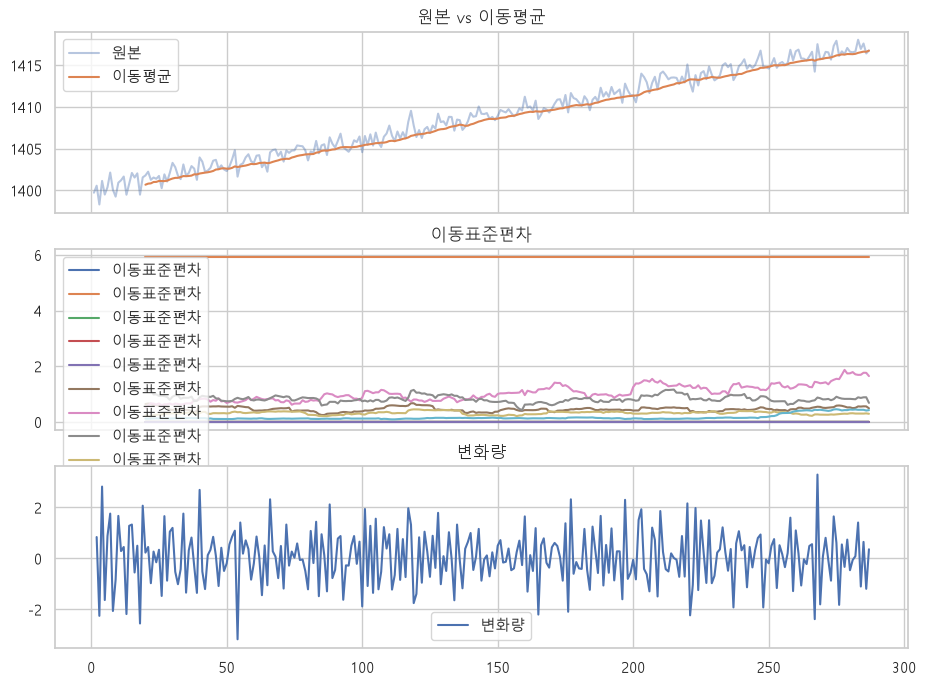

In [8]:
eng_02 = df[df["unit_nr"] == 2]
print(eng_02.shape) # (287, 10)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

ax1.set_title("원본 vs 이동평균")
ma = eng_02["s_4"].rolling(20).mean()
ax1.plot(eng_02["time_cycles"], eng_02["s_4"], label="원본", alpha=0.4)
ax1.plot(eng_02["time_cycles"], ma, label="이동평균")
ax1.legend()

ax2.set_title("이동표준편차")
std = eng_02.rolling(20).std()
ax2.plot(eng_02["time_cycles"], std, label="이동표준편차")
ax2.legend()

ax3.set_title("변화량")
diff = eng_02["s_4"].diff()
ax3.plot(eng_02["time_cycles"], diff, label="변화량")
ax3.legend()

plt.show()